In [1]:
# TUGAS 1: Logistic Regression pada Dataset Iris
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pandas as pd
import numpy as np

# Load dataset Iris
iris = load_iris()
print("Dataset Iris loaded!")
print(f"Jumlah data: {iris.data.shape[0]} baris")
print(f"Jumlah fitur: {iris.data.shape[1]} fitur")
print(f"Nama fitur: {iris.feature_names}")
print(f"Nama kelas: {iris.target_names}")
print(f"Distribusi kelas: {np.bincount(iris.target)}")

# Membagi data menjadi data latih (80%) dan data uji (20%)
X_train, X_test, y_train, y_test = train_test_split(
    iris.data, iris.target, test_size=0.2, random_state=42, stratify=iris.target
)

print(f"\nData latih: {X_train.shape[0]} sampel")
print(f"Data uji: {X_test.shape[0]} sampel")

# Membuat dan melatih model Logistic Regression
# max_iter=200 untuk memastikan model konvergen
lr_model = LogisticRegression(max_iter=200, random_state=42)
lr_model.fit(X_train, y_train)

# Memprediksi data uji
y_pred_lr = lr_model.predict(X_test)
y_pred_proba = lr_model.predict_proba(X_test)

# Evaluasi model
accuracy_lr = accuracy_score(y_test, y_pred_lr)
cm_lr = confusion_matrix(y_test, y_pred_lr)
report_lr = classification_report(y_test, y_pred_lr, target_names=iris.target_names)

print("\n" + "="*60)
print("HASIL LOGISTIC REGRESSION")
print("="*60)
print(f"Accuracy: {accuracy_lr:.3f}")
print(f"\nConfusion Matrix:")
print(cm_lr)
print(f"\nClassification Report:")
print(report_lr)

# Menampilkan probabilitas prediksi untuk 5 data pertama
print("\nProbabilitas prediksi (5 data pertama):")
proba_df = pd.DataFrame(y_pred_proba[:5], columns=iris.target_names)
proba_df['Prediksi'] = iris.target_names[y_pred_lr[:5]]
proba_df['Aktual'] = iris.target_names[y_test[:5]]
print(proba_df.round(3))

Dataset Iris loaded!
Jumlah data: 150 baris
Jumlah fitur: 4 fitur
Nama fitur: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Nama kelas: ['setosa' 'versicolor' 'virginica']
Distribusi kelas: [50 50 50]

Data latih: 120 sampel
Data uji: 30 sampel

HASIL LOGISTIC REGRESSION
Accuracy: 0.967

Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30


Probabilitas prediksi (5 data pertama):
   setosa  versicolor  virginica    Prediksi      Aktual
0   0.985       0.015      0.000      setosa      setosa
1   0.001       0.391      0.608   virginica   virginica
2 


HASIL DECISION TREE
Accuracy: 0.967

Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



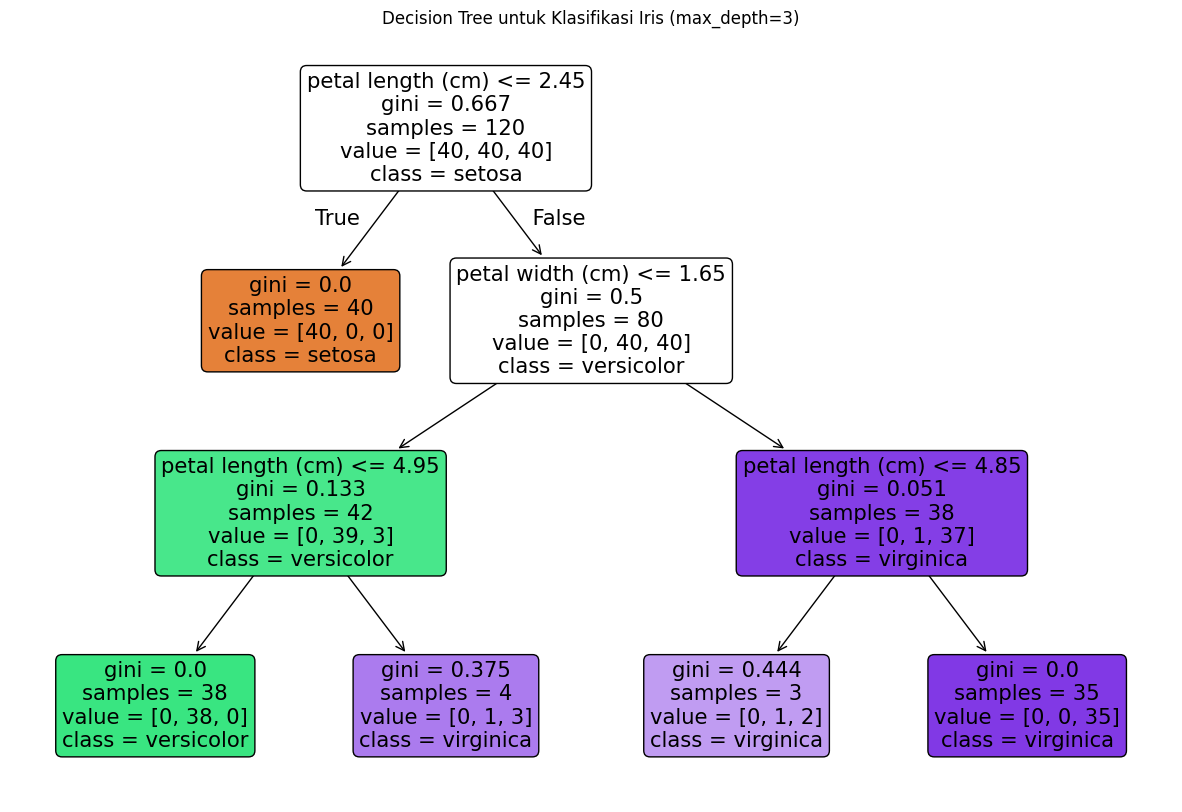


Aturan Keputusan (sederhana):
1. Jika petal length ≤ 2.45 cm → Setosa
2. Jika petal length > 2.45 cm dan petal width ≤ 1.75 cm → Versicolor
3. Jika petal length > 2.45 cm dan petal width > 1.75 cm → Virginica


In [2]:
# TUGAS 2: Decision Tree pada Dataset Iris
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt

# Load dataset Iris (gunakan data yang sama)
iris = load_iris()
X_train, X_test, y_train, y_test = train_test_split(
    iris.data, iris.target, test_size=0.2, random_state=42, stratify=iris.target
)

# Membuat dan melatih model Decision Tree
# max_depth=3 untuk mencegah overfitting
dt_model = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_model.fit(X_train, y_train)

# Memprediksi data uji
y_pred_dt = dt_model.predict(X_test)

# Evaluasi model
accuracy_dt = accuracy_score(y_test, y_pred_dt)
cm_dt = confusion_matrix(y_test, y_pred_dt)
report_dt = classification_report(y_test, y_pred_dt, target_names=iris.target_names)

print("\n" + "="*60)
print("HASIL DECISION TREE")
print("="*60)
print(f"Accuracy: {accuracy_dt:.3f}")
print(f"\nConfusion Matrix:")
print(cm_dt)
print(f"\nClassification Report:")
print(report_dt)

# Visualisasi Decision Tree
plt.figure(figsize=(15, 10))
plot_tree(dt_model, feature_names=iris.feature_names, 
          class_names=iris.target_names, filled=True, rounded=True)
plt.title("Decision Tree untuk Klasifikasi Iris (max_depth=3)")
plt.show()

# Menampilkan aturan keputusan sederhana
print("\nAturan Keputusan (sederhana):")
print("1. Jika petal length ≤ 2.45 cm → Setosa")
print("2. Jika petal length > 2.45 cm dan petal width ≤ 1.75 cm → Versicolor")
print("3. Jika petal length > 2.45 cm dan petal width > 1.75 cm → Virginica")


PERBANDINGAN METRIK LOGISTIC REGRESSION VS DECISION TREE
Metrik               Logistic Regression       Decision Tree            
----------------------------------------------------------------------
Accuracy             0.967                     0.967                    
Precision (macro)    0.970                     0.970                    
Recall (macro)       0.967                     0.967                    
F1-Score (macro)     0.967                     0.967                    


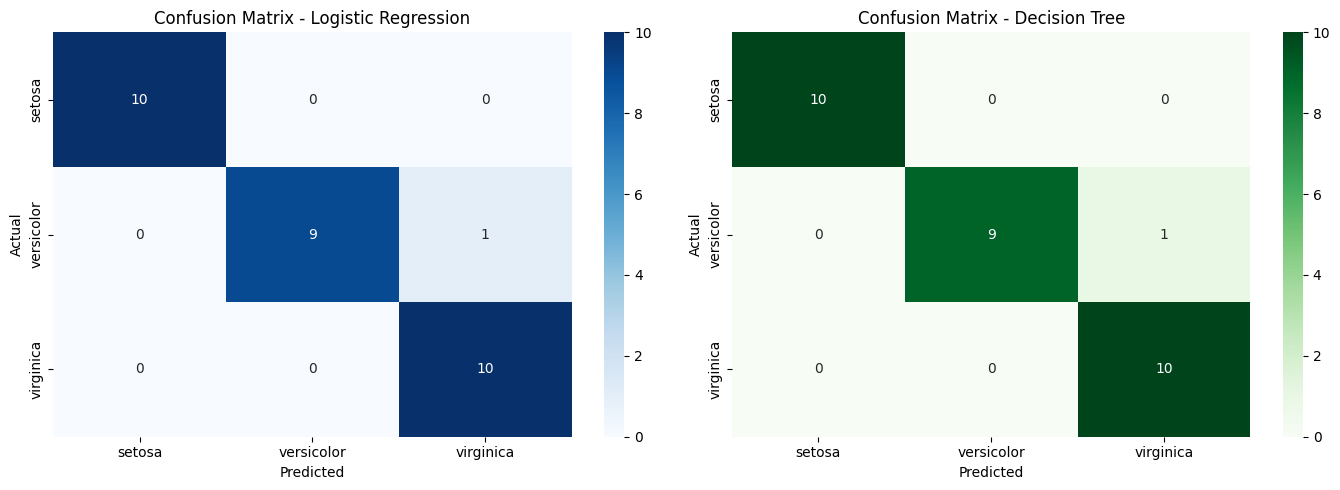

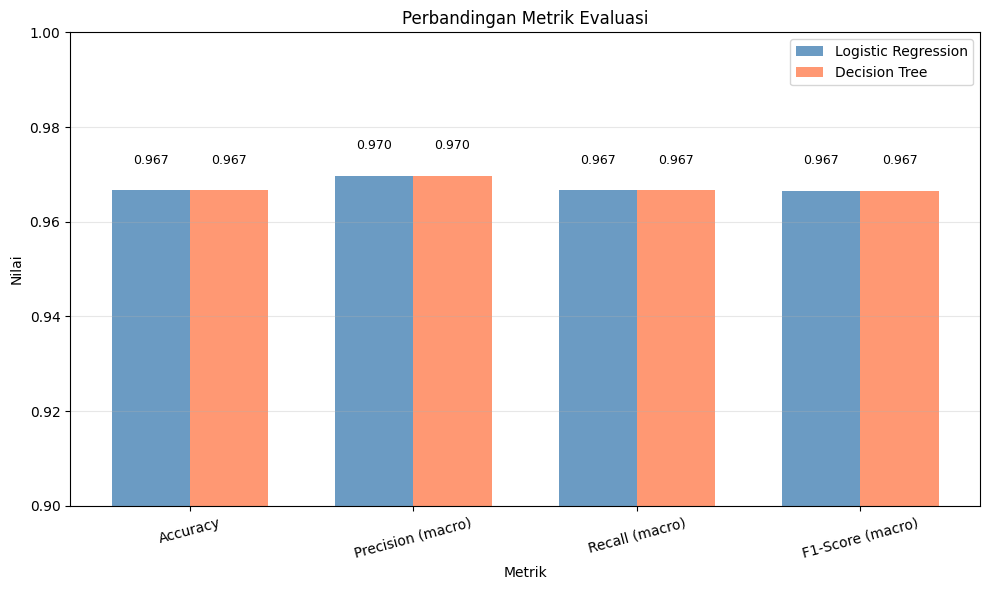

In [3]:
# TUGAS 3: Perbandingan Logistic Regression vs Decision Tree
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Load data
iris = load_iris()
X_train, X_test, y_train, y_test = train_test_split(
    iris.data, iris.target, test_size=0.2, random_state=42, stratify=iris.target
)

# Latih kedua model
lr_model = LogisticRegression(max_iter=200, random_state=42)
lr_model.fit(X_train, y_train)

dt_model = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_model.fit(X_train, y_train)

# Prediksi
y_pred_lr = lr_model.predict(X_test)
y_pred_dt = dt_model.predict(X_test)

# Hitung metrik untuk kedua model
metrics = {}
for name, y_pred in [("Logistic Regression", y_pred_lr), ("Decision Tree", y_pred_dt)]:
    metrics[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision (macro)': precision_score(y_test, y_pred, average='macro'),
        'Recall (macro)': recall_score(y_test, y_pred, average='macro'),
        'F1-Score (macro)': f1_score(y_test, y_pred, average='macro')
    }

# Tampilkan perbandingan
print("\n" + "="*70)
print("PERBANDINGAN METRIK LOGISTIC REGRESSION VS DECISION TREE")
print("="*70)
print(f"{'Metrik':<20} {'Logistic Regression':<25} {'Decision Tree':<25}")
print("-"*70)
for metric in ['Accuracy', 'Precision (macro)', 'Recall (macro)', 'F1-Score (macro)']:
    print(f"{metric:<20} {metrics['Logistic Regression'][metric]:<25.3f} {metrics['Decision Tree'][metric]:<25.3f}")

# Visualisasi perbandingan
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix Logistic Regression
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='d', 
            xticklabels=iris.target_names, yticklabels=iris.target_names,
            cmap='Blues', ax=axes[0])
axes[0].set_title('Confusion Matrix - Logistic Regression')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Confusion Matrix Decision Tree
sns.heatmap(confusion_matrix(y_test, y_pred_dt), annot=True, fmt='d',
            xticklabels=iris.target_names, yticklabels=iris.target_names,
            cmap='Greens', ax=axes[1])
axes[1].set_title('Confusion Matrix - Decision Tree')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

# Bar chart perbandingan metrik
plt.figure(figsize=(10, 6))
x = np.arange(len(metrics['Logistic Regression'].keys()))
width = 0.35

lr_values = list(metrics['Logistic Regression'].values())
dt_values = list(metrics['Decision Tree'].values())

plt.bar(x - width/2, lr_values, width, label='Logistic Regression', color='steelblue', alpha=0.8)
plt.bar(x + width/2, dt_values, width, label='Decision Tree', color='coral', alpha=0.8)

plt.xlabel('Metrik')
plt.ylabel('Nilai')
plt.title('Perbandingan Metrik Evaluasi')
plt.xticks(x, list(metrics['Logistic Regression'].keys()), rotation=15)
plt.legend()
plt.ylim(0.9, 1.0)
plt.grid(axis='y', alpha=0.3)

# Tambah nilai di atas bar
for i, v in enumerate(lr_values):
    plt.text(i - width/2, v + 0.005, f'{v:.3f}', ha='center', va='bottom', fontsize=9)
for i, v in enumerate(dt_values):
    plt.text(i + width/2, v + 0.005, f'{v:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()